Parallel WorkFlow Using LangGraph & Groq (Llama-3.3-70B)

In [ ]:

from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
import operator
import os
load_dotenv()

True

In [6]:
# Initialize Groq LLM
# Llama-3.3-70b-versatile provides excellent structured output capabilities
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

In [7]:
# Define Pydantic Models for Structured Output
class EvaluationScore(BaseModel):
    feedback: str = Field(description="Detailed feedback")
    score: int = Field(description="Score out of 10")

# Create a structured output chain
structured_llm = llm.with_structured_output(EvaluationScore)

In [8]:
# Define Graph State
class EssayState(TypedDict):
    essay: str
    lang_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_score: Annotated[list[int], operator.add]

In [9]:
essay = """Education is one of the most important part of human life. It not only give us knowledge but also help us to understand the world around us. In today modern era, education become more necessary then ever before, because without education a person can not survive properly in society. Peoples who are educated have more chances to get good jobs and better life.

Firstly, education helps us to develop our thinking ability. When a student goes to school, he or she learn many subjects like science, math, and history. These subjects increase their understanding and make their mind more active. But sometime students only focus on passing exams instead of actually learning the concepts, which is not a good habit. Education should not be only for marks, it should be for gaining real knowledge.

Secondly, education also play important role in building character of a person. It teach us moral values, discipline, and respect for others. For example, in schools teachers always guide students to behave well and follow rules. However, in some cases education system fail to teach practical life skills, which is also very important for future life. A educated person who lack good behavior can not be considered fully educated.

Another important aspect is that education help in economic growth of a country. When more peoples are educated, they can work in different sectors and improve productivity. This leads to development of nation. On the other hand, lack of education can cause unemployment and poverty. Many developing countries are still struggling because they dont have proper education system for all citizens.

Moreover, education also promote equality in society. It give equal opportunities to both men and women. In past, women was not allowed to get education in many societies, but now situation is changing. Still, in some areas girls are not going to schools due to cultural or financial problems, which should be solved by government and communities.

In conclusion, education is very essential for personal and social development. It not only improve individual life but also help in progress of society. We should try to make education accessible to everyone and also improve quality of education system. Without proper education, no nation can achieve success in long term.
"""

In [10]:
# Define Workflow Nodes
# Each node gets executed in parallel when triggered from START

def evaluate_lang(state: EssayState) -> EssayState:
    prompt = f"Evaluate the language quality (grammar, vocabulary, syntax) of this essay.\n\nEssay: {state['essay']}"
    result = structured_llm.invoke(prompt)
    return {
        "lang_feedback": result.feedback,
        "individual_score": [result.score]
    }

def evaluate_analysis(state: EssayState) -> EssayState:
    prompt = f"Evaluate the depth of analysis and critical thinking in this essay.\n\nEssay: {state['essay']}"
    result = structured_llm.invoke(prompt)
    return {
        "analysis_feedback": result.feedback,
        "individual_score": [result.score]
    }

def evaluate_clarity(state: EssayState) -> EssayState:
    prompt = f"Evaluate the clarity and structure of this essay.\n\nEssay: {state['essay']}"
    result = structured_llm.invoke(prompt)
    return {
        "clarity_feedback": result.feedback,
        "individual_score": [result.score]
    }

def final_evaluation(state: EssayState) -> EssayState:
    # This node aggregates the parallel outputs
    avg = round(sum(state["individual_score"]) / len(state["individual_score"]), 2)
    summary = f"""
=== FINAL EVALUATION ===
Language Feedback : {state['lang_feedback']}
Analysis Feedback : {state['analysis_feedback']}
Clarity Feedback  : {state['clarity_feedback']}
Individual Scores : {state['individual_score']}
Average Score     : {avg}/10
"""
    return {"overall_feedback": summary}

In [11]:
# Build Parallel Execution Graph
graph = StateGraph(EssayState)

graph.add_node("evaluate_lang", evaluate_lang)
graph.add_node("evaluate_analysis", evaluate_analysis)
graph.add_node("evaluate_clarity", evaluate_clarity)
graph.add_node("final_evaluation", final_evaluation)

# Parallel execution: START connects to all 3 evaluators
graph.add_edge(START, "evaluate_lang")
graph.add_edge(START, "evaluate_analysis")
graph.add_edge(START, "evaluate_clarity")

# All 3 evaluators connect to final_evaluation
graph.add_edge("evaluate_lang", "final_evaluation")
graph.add_edge("evaluate_analysis", "final_evaluation")
graph.add_edge("evaluate_clarity", "final_evaluation")

graph.add_edge("final_evaluation", END)

workflow = graph.compile()

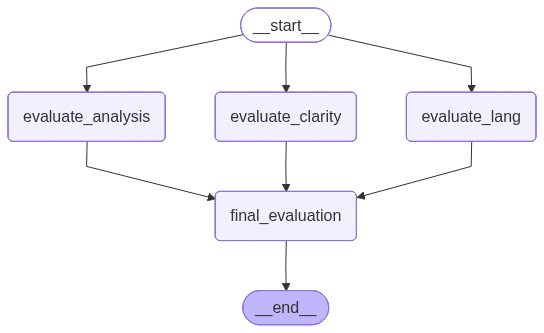

In [12]:
workflow

In [13]:
# Run the Parallel Workflow
initial_state = {
    "essay": essay,
    "lang_feedback": "",
    "analysis_feedback": "",
    "clarity_feedback": "",
    "overall_feedback": "",
    "individual_score": []
}

final_state = workflow.invoke(initial_state)
print(final_state["overall_feedback"])


=== FINAL EVALUATION ===
Language Feedback : The essay demonstrates a good understanding of the importance of education in human life, and the writer provides several relevant points to support their argument. However, there are some areas that need improvement. The grammar and syntax are sometimes incorrect, such as 'Education is one of the most important part of human life' (should be 'parts'), 'peoples who are educated' (should be 'people'), and 'in today modern era' (should be 'in today's modern era'). Additionally, the vocabulary could be more varied and sophisticated. The writer also tends to make general statements without providing specific examples or evidence to support them. Overall, the essay is well-structured and easy to follow, but could benefit from more attention to detail and refinement of language.
Analysis Feedback : The essay demonstrates a good understanding of the importance of education in human life, but the depth of analysis and critical thinking can be impro